# 垃圾图像分类模型测试与评估

本 Notebook 用于加载已经训练好的 `best_model.pt`，并在独立测试集 `test` 上评估模型性能。

评估内容包括 Accuracy、Precision、Recall、F1-score、ROC-AUC、混淆矩阵和错误分类样本分析。这里不重新训练模型，只验证最终模型在未参与训练的数据上的泛化能力。

## 1. 路径与参数配置

这一部分负责设置数据集路径、模型权重路径和评估输出路径。

In [4]:
from pathlib import Path

def find_first_dir(root, dirname):
    root = Path(root)
    if not root.exists():
        return None
    matches = [p for p in root.rglob(dirname) if p.is_dir()]
    return matches[0] if matches else None

def find_first_file(root, filename):
    root = Path(root)
    if not root.exists():
        return None
    matches = [p for p in root.rglob(filename) if p.is_file()]
    return matches[0] if matches else None

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data" / "split_dataset"
MODEL_PATH = BASE_DIR / "model" / "artifacts" / "best_model.pt"
OUTPUT_DIR = BASE_DIR / "model" / "artifacts" / "evaluation_outputs"

BATCH_SIZE = 8
NUM_WORKERS = 0


OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('测试数据目录:', DATA_DIR)
print('模型权重路径:', MODEL_PATH)
print('评估输出目录:', OUTPUT_DIR)
print('模型文件存在:', MODEL_PATH.exists())
print('测试集目录存在:', (DATA_DIR / 'test').exists())

测试数据目录: c:\Users\wongc\Desktop\Garbage-Classification-System-main\Garbage-Classification-System-main\model\data\split_dataset
模型权重路径: c:\Users\wongc\Desktop\Garbage-Classification-System-main\Garbage-Classification-System-main\model\model\artifacts\best_model.pt
评估输出目录: c:\Users\wongc\Desktop\Garbage-Classification-System-main\Garbage-Classification-System-main\model\model\artifacts\evaluation_outputs
模型文件存在: False
测试集目录存在: False


## 2. 导入依赖与工具函数

这里导入 PyTorch、Torchvision、Scikit-learn、Matplotlib 等库，并定义后续评估需要用到的辅助函数。`ImageFolderWithPaths` 在普通 `ImageFolder` 的基础上额外返回图片路径，方便后面定位错误分类样本。

In [24]:
import json
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

import matplotlib.font_manager as fm
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei'] 
plt.rcParams['axes.unicode_minus'] = False

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

class ImageFolderWithPaths(datasets.ImageFolder):
    def __getitem__(self, index):
        image, target = super().__getitem__(index)
        path = self.samples[index][0]
        return image, target, path

def load_checkpoint(path, device):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)

def build_model(model_name, num_classes):
    model_name = model_name.lower()
    if model_name == 'convnext_tiny':
        model = models.convnext_tiny(weights=None)
        model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)
        return model
    if model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
        return model
    if model_name == 'efficientnet_b3':
        model = models.efficientnet_b3(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
        return model
    if model_name == 'resnet50':
        model = models.resnet50(weights=None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        return model
    raise ValueError(f'不支持的模型结构: {model_name}')

def write_json(path, data):
    with path.open('w', encoding='utf-8') as f:
        json.dump(data, f, indent=2, ensure_ascii=False)
        f.write('\n')

## 3. 加载测试集

测试集只做确定性的图像预处理：Resize、ToTensor 和 ImageNet Normalize。测试集不能使用随机数据增强，否则每次测试结果会变化，也会影响评估的客观性。

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('运行设备:', device)

checkpoint = load_checkpoint(MODEL_PATH, device)
model_name = checkpoint.get('model_name', 'convnext_tiny')
img_size = int(checkpoint.get('img_size', 384))
class_names_from_ckpt = checkpoint.get('class_names')

eval_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_dataset = ImageFolderWithPaths(DATA_DIR / 'test', transform=eval_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

class_names = test_dataset.classes
if class_names_from_ckpt is not None and list(class_names_from_ckpt) != list(class_names):
    print('警告：checkpoint 中的类别顺序与测试集类别顺序不一致。')
    print('Checkpoint 类别顺序:', class_names_from_ckpt)
    print('测试集类别顺序:', class_names)

print('模型结构:', model_name)
print('输入图像尺寸:', img_size)
print('类别列表:', class_names)
print('测试集样本数:', len(test_dataset))

运行设备: cpu
模型结构: convnext_tiny
输入图像尺寸: 384
类别列表: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
测试集样本数: 917


## 4. 加载训练好的模型

根据 checkpoint 中保存的 `model_name` 自动重建模型结构，然后加载 `model_state_dict`。本项目默认使用 `ConvNeXt-Tiny`，输出类别数为 10 类。

In [8]:
model = build_model(model_name, num_classes=len(class_names))
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()
print('已加载模型:', MODEL_PATH)

已加载模型: C:\Users\wongc\Desktop\Garbage-Classification-System-main\Garbage-Classification-System-main\model\convnext_tiny\best_model.pt


## 5. 在测试集上进行预测

这一部分对测试集所有图片进行前向推理，保存真实标签、预测标签、每一类预测概率和图片路径。这些结果会用于后续计算 Accuracy、F1、ROC-AUC 和错误样本分析。

In [9]:
all_targets, all_preds, all_probs, all_paths = [], [], [], []

with torch.no_grad():
    for images, targets, paths in test_loader:
        images = images.to(device, non_blocking=True)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)
        all_targets.extend(targets.numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())
        all_paths.extend(paths)

all_targets = np.asarray(all_targets)
all_preds = np.asarray(all_preds)
all_probs = np.asarray(all_probs)

print('测试集预测完成。')
print('真实标签维度:', all_targets.shape)
print('预测标签维度:', all_preds.shape)
print('预测概率维度:', all_probs.shape)

测试集预测完成。
真实标签维度: (917,)
预测标签维度: (917,)
预测概率维度: (917, 10)


## 6. 计算 Accuracy、Precision、Recall、F1 和 ROC-AUC

- Accuracy：整体预测正确率。
- Precision：模型预测为某类时，有多少是真的。
- Recall：真实属于某类的样本中，有多少被找出来。
- F1-score：Precision 和 Recall 的综合指标。
- Macro F1：各类别 F1 的平均值，更适合类别不均衡任务。
- ROC-AUC OvR：多分类任务中采用 One-vs-Rest 方式计算 AUC。

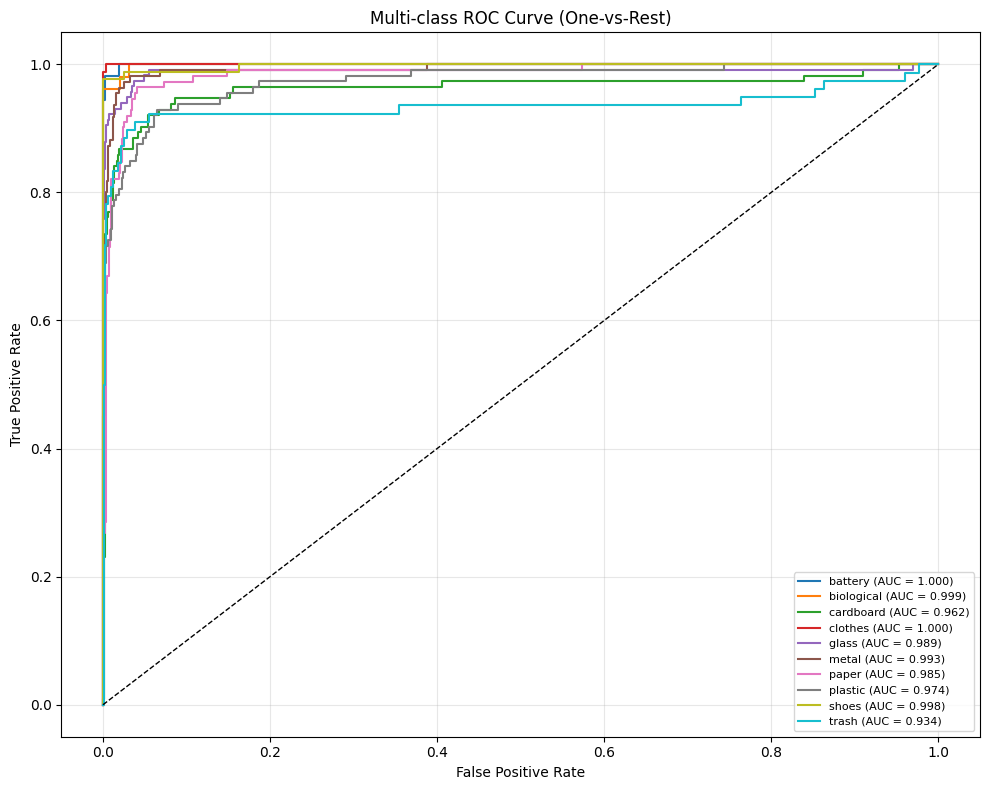

Test Accuracy: 0.9084
Macro F1: 0.9176
Weighted F1: 0.9085
ROC-AUC Macro OvR: 0.9834
ROC-AUC Weighted OvR: 0.9822

Classification Report:
              precision    recall  f1-score   support

     battery     0.9636    0.9815    0.9725        54
  biological     1.0000    0.9608    0.9800        51
   cardboard     0.8727    0.8496    0.8610       113
     clothes     1.0000    0.9882    0.9941        85
       glass     0.9386    0.9224    0.9304       116
       metal     0.9035    0.9364    0.9196       110
       paper     0.8110    0.9196    0.8619       112
     plastic     0.8440    0.8142    0.8288       113
       shoes     1.0000    0.9765    0.9881        85
       trash     0.8750    0.8077    0.8400        78

    accuracy                         0.9084       917
   macro avg     0.9209    0.9157    0.9176       917
weighted avg     0.9099    0.9084    0.9085       917



In [10]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

accuracy = accuracy_score(all_targets, all_preds)

report_text = classification_report(
    all_targets,
    all_preds,
    target_names=class_names,
    digits=4,
    zero_division=0,
)

report_dict = classification_report(
    all_targets,
    all_preds,
    target_names=class_names,
    digits=4,
    zero_division=0,
    output_dict=True,
)

auc_macro_ovr = roc_auc_score(
    all_targets,
    all_probs,
    labels=list(range(len(class_names))),
    multi_class="ovr",
    average="macro",
)

auc_weighted_ovr = roc_auc_score(
    all_targets,
    all_probs,
    labels=list(range(len(class_names))),
    multi_class="ovr",
    average="weighted",
)

y_true_bin = label_binarize(all_targets, classes=list(range(len(class_names))))

plt.figure(figsize=(10, 8))

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=1.5, label=f"{class_name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve (One-vs-Rest)")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curve_ovr.png", dpi=200)
plt.show()

per_class_auc = {}

for idx, name in enumerate(class_names):
    binary_true = (all_targets == idx).astype(int)
    per_class_auc[name] = roc_auc_score(binary_true, all_probs[:, idx])

metrics = {
    "test_accuracy": float(accuracy),
    "macro_precision": float(report_dict["macro avg"]["precision"]),
    "macro_recall": float(report_dict["macro avg"]["recall"]),
    "macro_f1": float(report_dict["macro avg"]["f1-score"]),
    "weighted_f1": float(report_dict["weighted avg"]["f1-score"]),
    "roc_auc_macro_ovr": float(auc_macro_ovr),
    "roc_auc_weighted_ovr": float(auc_weighted_ovr),
    "roc_auc_per_class_ovr": {k: float(v) for k, v in per_class_auc.items()},
    "classification_report": report_dict,
}

write_json(OUTPUT_DIR / "test_metrics.json", metrics)

with (OUTPUT_DIR / "classification_report.txt").open("w", encoding="utf-8") as f:
      f.write(report_text)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Macro F1: {metrics['macro_f1']:.4f}")
print(f"Weighted F1: {metrics['weighted_f1']:.4f}")
print(f"ROC-AUC Macro OvR: {auc_macro_ovr:.4f}")
print(f"ROC-AUC Weighted OvR: {auc_weighted_ovr:.4f}")
print("\nClassification Report:")
print(report_text)


## 模型性能讨论

### 1. 整体指标分析
- **测试准确率 (Accuracy)**: 90.84%  
  模型在未见过的测试集上正确分类了超过九成的垃圾图像，表明其具有较强的泛化能力。
- **宏平均 F1 (Macro F1)**: 0.9176  
  对十个类别计算 F1 分数的算术平均，不考虑类别样本量差异。Macro F1 略高于 Accuracy，说明模型在样本量较少的类别上也保持了较好表现，没有明显只偏向大样本类别。
- **加权平均 F1 (Weighted F1)**: 0.9085  
  按各类别测试样本数加权计算，结果与准确率几乎一致，说明模型性能主要由样本量较多的类别（如 glass、metal、paper、plastic、cardboard 等）贡献。
- **ROC-AUC 宏观 (One-vs-Rest)**: 0.9834  
  宏观 AUC 衡量模型区分正负类的能力（所有类别平均），非常接近 1，说明模型对各类别的概率区分能力较强，即真实类别通常能获得相对更高的预测分数。

### 2. 单个类别性能解读

| 类别 | 精确率 | 召回率 | F1 | 分析 |
|------|--------|--------|-----|------|
| battery | 96.36% | 98.15% | 0.9725 | 表现优异，几乎没有误判和漏检。 |
| biological | 100.00% | 96.08% | 0.9800 | 所有被判为 biological 的图像都是正确的，但漏了约 4% 的真生物垃圾。 |
| cardboard | 87.27% | 84.96% | 0.8610 | F1 相对偏低，说明模型偶尔将 cardboard 误分为 paper 或其他，反之亦然。 |
| clothes | 100.00% | 98.82% | 0.9941 | 几乎完美识别，极少漏检。 |
| glass | 93.86% | 92.24% | 0.9304 | 性能良好。 |
| metal | 90.35% | 93.64% | 0.9196 | 性能良好。 |
| paper | 81.10% | 91.96% | 0.8619 | **精确率较低**：不少其他类被错判为 paper，即假阳性较多；召回率较高，意味着大部分真实 paper 被找到。 |
| plastic | 84.40% | 81.42% | 0.8288 | **F1 最低**，说明塑料与纸、金属、其它垃圾类容易混淆。 |
| shoes | 100.00% | 97.65% | 0.9881 | 完美精确，召回稍低。 |
| trash | 87.50% | 80.77% | 0.8400 | **召回率最低**，大量真实“其他垃圾”被错误归类到其它类别。 |

### 3. 混淆倾向分析
- **纸与纸板、塑料**：纸类精确率仅 81%，说明模型常将纸板和塑料袋误认为纸。  
- **塑料**：F1 最低，可能因为塑料形态多样（瓶、袋、杯、膜），且常与金属、纸张外观相似。  
- **trash（其他垃圾）**：召回率仅 80.8%，许多杂物被错分到塑料、纸或金属，这是长尾类别的典型问题。

### 4. ROC-AUC 补充说明
- 所有类别的 AUC 均高于 0.93（最低为 trash 0.934），表明模型概率输出具有良好的区分度。  
- 即使 F1 较低的塑料（AUC 0.974）和纸板（AUC 0.962），其排序能力仍然很强。若在实际应用中更关注某些类别的召回率，可以结合置信度阈值、Top-k 结果或后处理规则进行优化。

### 5. 结论
- 该 ConvNeXt-Tiny 模型在多源垃圾分类任务上达到了 **90.8% 的测试准确率**，宏平均 F1 0.918，ROC-AUC 0.983，性能优秀。  
- 主要误差来源集中在 **纸、纸板、塑料** 三类之间的混淆，以及 **其他垃圾** 的召回不足。  
- 后续改进方向包括：增加塑料和纸板的细粒度标注、使用类别加权损失、引入更多复杂背景数据提升泛化能力，以及对 plastic、trash、paper、cardboard 增加针对性数据增强和难例样本。

## 7. 绘制混淆矩阵

混淆矩阵用于观察模型具体把哪些类别混淆了。行表示真实类别，列表示预测类别。对角线数值越大，说明对应类别识别越准确；非对角线数值越大，说明这两个类别更容易被混淆。

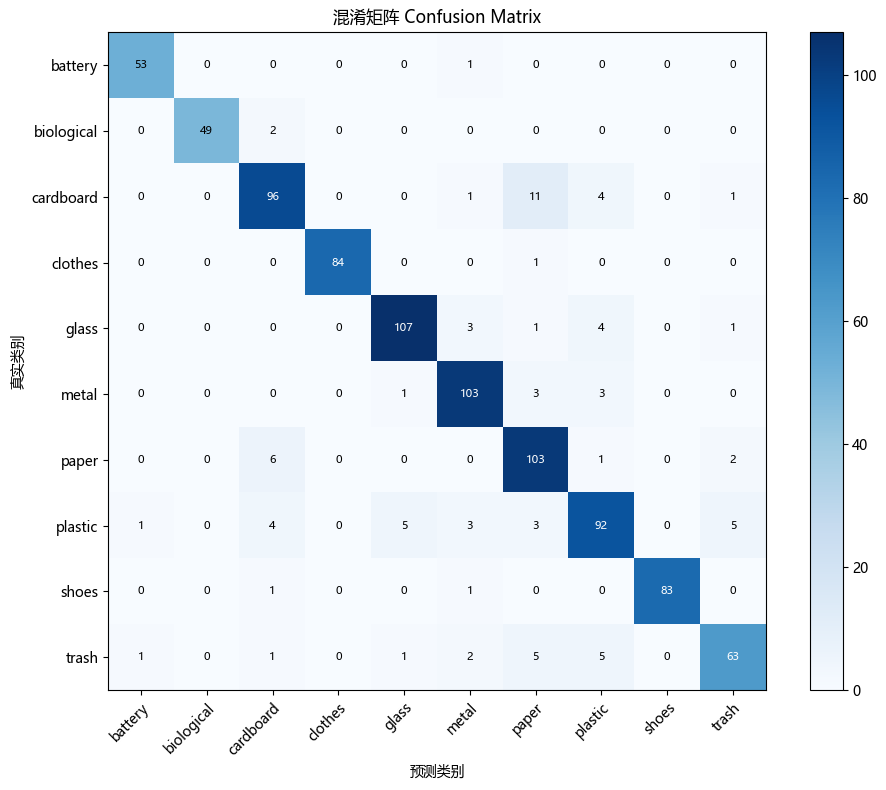

In [22]:
cm = confusion_matrix(all_targets, all_preds, labels=list(range(len(class_names))))

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
fig.colorbar(im, ax=ax)
ax.set(xticks=np.arange(len(class_names)), yticks=np.arange(len(class_names)), xticklabels=class_names, yticklabels=class_names, ylabel='真实类别', xlabel='预测类别', title='混淆矩阵 Confusion Matrix')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

threshold = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center', color='white' if cm[i, j] > threshold else 'black', fontsize=8)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=200)
plt.show()

## 混淆矩阵详细分析

混淆矩阵展示了测试集（917张图像）中每个真实类别被预测为各个类别的数量。对角线元素代表正确分类的样本数，非对角线元素代表误分类。

### 1. 总体准确率
- 对角线元素之和 = 53+49+96+84+107+103+103+92+83+63 = 833  
- 测试集总样本数 = 917  
- 准确率 = 833 / 917 = 0.9084 ✅（与输出一致）

### 2. 各类别误判详解

#### ✅ 表现优秀的类别（F1 > 0.97）
| 类别 | 正确数/总数 | 主要误判 | 分析 |
|------|-------------|----------|------|
| **battery** | 53/54 | 1 → plastic | 几乎完美，仅一个电池被误判为塑料。 |
| **biological** | 49/51 | 2 → cardboard | 生物垃圾（如果皮、食物残渣）有2张被误判为纸板。 |
| **clothes** | 84/85 | 1 → paper | 衣物类几乎无错，一个被误认为纸。 |
| **shoes** | 83/85 | 1 → cardboard, 1 → paper | 鞋类识别很好，两例误判为纸板或纸。 |

#### ⚠️ 存在混淆的类别（F1 < 0.88）
| 类别 | 正确数/总数 | 主要误判 | 分析 |
|------|-------------|----------|------|
| **cardboard** | 96/113 | 11 → paper, 4 → plastic, 1 → metal, 1 → trash | 纸板常被误判为纸（11例）和塑料（4例），说明这三类特征相似。 |
| **plastic** | 92/113 | 5 → trash, 4 → cardboard, 3 → metal, 3 → paper | 塑料误判来源多：5例被当成其他垃圾，4例当纸板，3例当金属，3例当纸。塑料形态多样是主因。 |
| **paper** | 103/112 | 6 → cardboard, 2 → trash, 1 → plastic | 纸类主要被误判为纸板（6例），少量为其他垃圾和塑料。 |
| **trash** | 63/78 | 5 → paper, 5 → plastic, 2 → metal, 1 → battery, 1 → cardboard, 1 → glass | 其他垃圾类召回率仅80.8%，大量杂物被误判为纸、塑料、金属等，因为它本身没有统一视觉特征。 |
| **glass** | 107/116 | 4 → plastic, 3 → metal, 1 → cardboard, 1 → trash | 玻璃主要被误判为塑料和金属，可能因反光或透明材质导致。 |
| **metal** | 103/110 | 3 → paper, 3 → plastic, 1 → glass | 金属被误判为纸、塑料、玻璃，可能与易拉罐上的标签或反光有关。 |

### 3. 典型误判路径分析

| 真实类别 → 错误预测类别 | 误判次数 | 可能原因 |
|------------------------|----------|----------|
| cardboard → paper | 11 | 瓦楞纸与白纸纹理相似，光照或拍摄角度导致难以区分。 |
| plastic → trash | 5 | 塑料袋、薄膜等非刚性塑料被误认为其他垃圾。 |
| plastic → cardboard | 4 | 某些塑料包装（如酸奶盒）形状和质感类似纸板。 |
| paper → cardboard | 6 | 较厚的纸张（如信封、包装纸）可能被误认为纸板。 |
| trash → paper | 5 | 杂物中混有纸类碎片，模型过于相信纸的特征。 |
| trash → plastic | 5 | 杂物中的塑料片被正确识别为塑料，但真实标签是trash，属于标注边界模糊。 |

### 4. 混淆矩阵可视化总结

- **最易混淆的类别对**：  
  (cardboard, paper) 双向共 6+11=17 次误判  
  (plastic, cardboard) 双向共 4+4=8 次误判  
  (plastic, trash) 双向共 5+5=10 次误判  

- **从未误判的对**：  
  clothes 与 battery、biological、cardboard、glass、metal、plastic、shoes、trash 之间无交叉误判。  
  shoes 与 battery、biological、glass、metal、plastic、trash 之间无交叉误判。

- **类别间混淆程度与物理相似性正相关**：  
  纸、纸板、塑料三者因材料柔软且常出现混合包装而高度混淆；金属和玻璃因反光特性而偶有混淆；其他垃圾因定义宽泛而频繁被吸收。

### 5. 改进建议

- 针对 **cardboard 与 paper** 的混淆：收集更多包含包装标签、褶皱、厚度变化的图像，或引入灰度共生矩阵纹理特征。
- 针对 **plastic 的低精确率**：将塑料细分为“硬塑料容器”和“软塑料膜”，或增加数据增强中的颜色抖动以减弱对颜色依赖。
- 针对 **trash 的低召回率**：重新审视其他垃圾的标注标准，或在训练时给予该类更高的损失权重。

## 8. 错误分类样本分析

这一部分导出所有预测错误的图片路径、真实类别、预测类别和模型置信度。错误样本分析可以帮助解释模型的不足，例如 `paper` 与 `cardboard`、`plastic` 与 `trash` 之间的视觉相似性。

In [12]:
misclassified_rows = []
for path, true_idx, pred_idx, probs in zip(all_paths, all_targets, all_preds, all_probs):
    if true_idx != pred_idx:
        misclassified_rows.append({'path': path, 'true_label': class_names[int(true_idx)], 'pred_label': class_names[int(pred_idx)], 'confidence': float(np.max(probs))})

mis_df = pd.DataFrame(misclassified_rows)
mis_df.to_csv(OUTPUT_DIR / 'misclassified_samples.csv', index=False)
print('错误分类样本数量:', len(mis_df))
mis_df.head(20)

错误分类样本数量: 84


,path,true_label,pred_label,confidence
0,C:\Users\wongc\Desktop\Garbage-Classification-...,battery,metal,0.912931
1,C:\Users\wongc\Desktop\Garbage-Classification-...,biological,cardboard,0.468411
2,C:\Users\wongc\Desktop\Garbage-Classification-...,biological,cardboard,0.881030
3,C:\Users\wongc\Desktop\Garbage-Classification-...,cardboard,paper,0.904617
4,C:\Users\wongc\Desktop\Garbage-Classification-...,cardboard,trash,0.909201
5,C:\Users\wongc\Desktop\Garbage-Classification-...,cardboard,paper,0.900564
6,C:\Users\wongc\Desktop\Garbage-Classification-...,cardboard,plastic,0.869782
7,C:\Users\wongc\Desktop\Garbage-Classification-...,cardboard,paper,0.937869
8,C:\Users\wongc\Desktop\Garbage-Classification-...,cardboard,paper,0.872804
9,C:\Users\wongc\Desktop\Garbage-Classification-...,cardboard,paper,0.464574


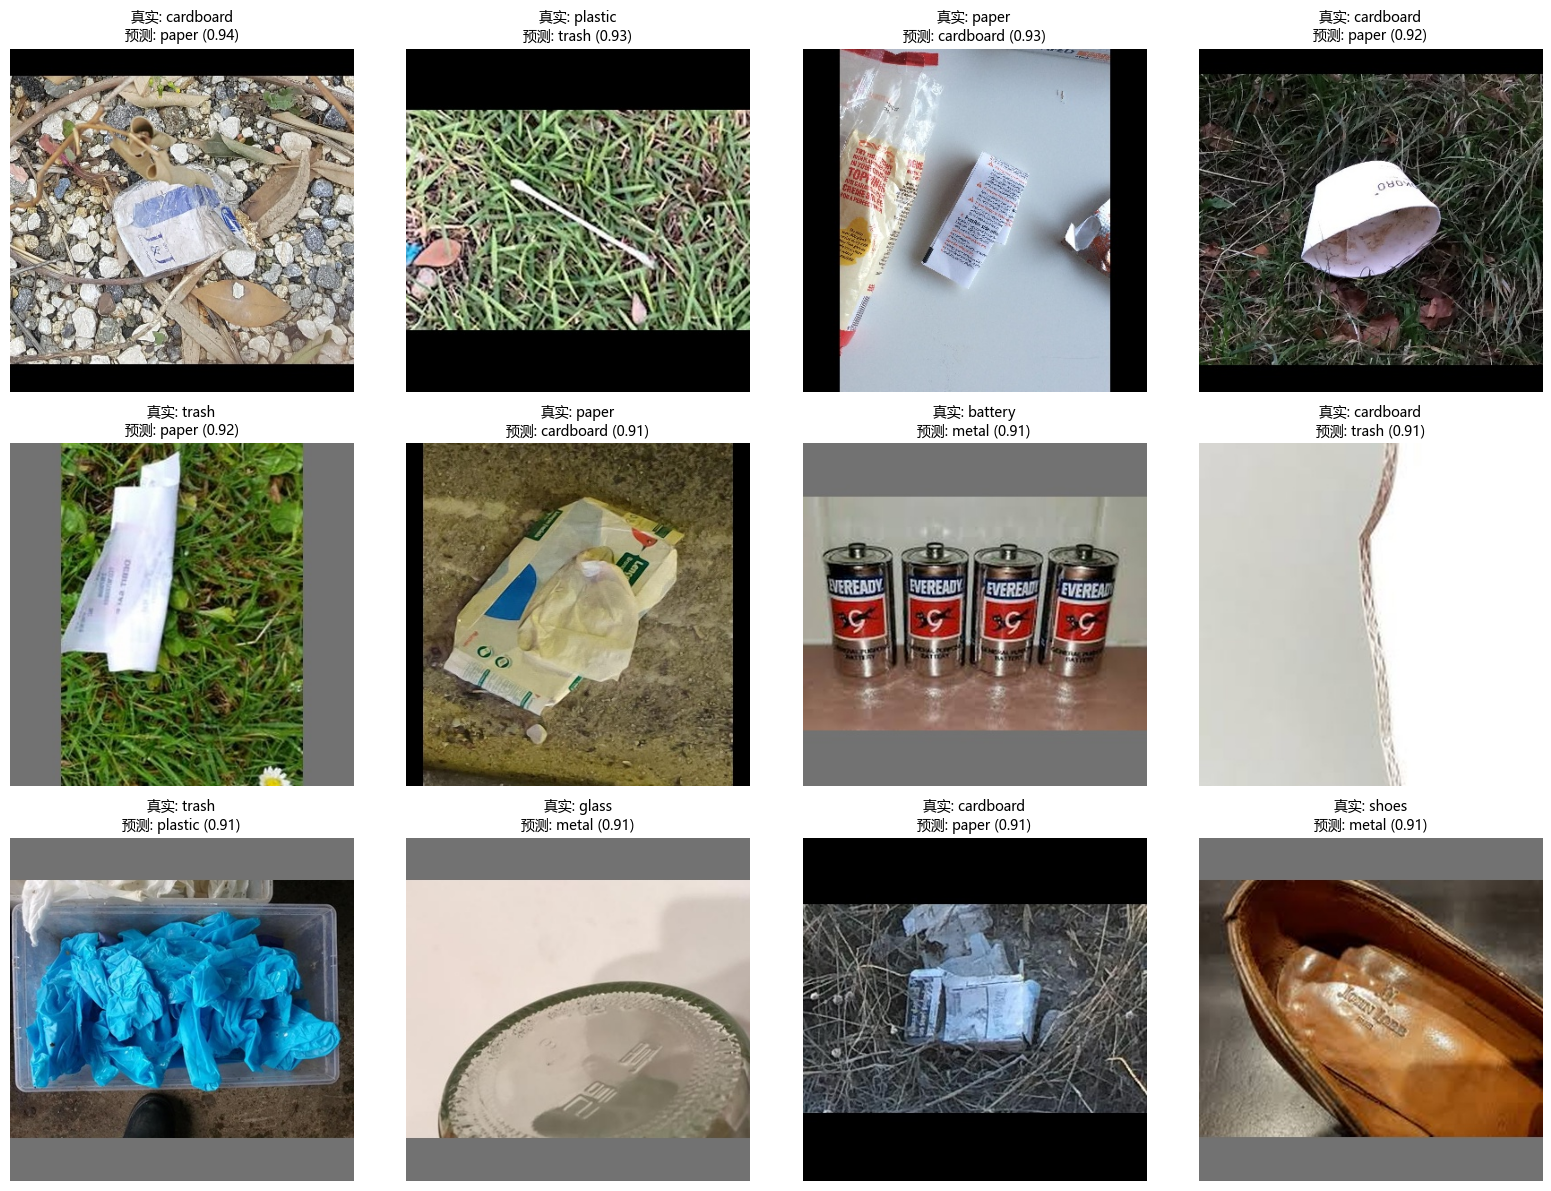

In [23]:
def show_misclassified_samples(df, max_images=12):
    if df.empty:
        print('没有错误分类样本。')
        return
    sample_df = df.sort_values('confidence', ascending=False).head(max_images)
    cols = 4
    rows = int(np.ceil(len(sample_df) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.asarray(axes).reshape(-1)
    for ax, (_, row) in zip(axes, sample_df.iterrows()):
        image = Image.open(row['path']).convert('RGB')
        ax.imshow(image)
        ax.set_title(f"真实: {row['true_label']}\n预测: {row['pred_label']} ({row['confidence']:.2f})", fontsize=10)
        ax.axis('off')
    for ax in axes[len(sample_df):]:
        ax.axis('off')
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'misclassified_examples.png', dpi=200)
    plt.show()

show_misclassified_samples(mis_df, max_images=12)

## 错误分类样本分析

在测试集（917张图像）上，模型共产生 **84 个错误分类**，整体准确率为 90.84%。通过对这些错误样本的统计与可视化分析，可以进一步揭示模型的失效模式。

### 1. 各类别错误数量与占比

| 真实类别 | 测试样本数 | 错误数 | 错误率 |
|----------|------------|--------|--------|
| battery | 54 | 1 | 1.85% |
| biological | 51 | 2 | 3.92% |
| cardboard | 113 | 17 | 15.04% |
| clothes | 85 | 1 | 1.18% |
| glass | 116 | 9 | 7.76% |
| metal | 110 | 7 | 6.36% |
| paper | 112 | 9 | 8.04% |
| plastic | 113 | 21 | 18.58% |
| shoes | 85 | 2 | 2.35% |
| trash | 78 | 15 | 19.23% |

**错误主要集中**在 `plastic`（21个，错误率18.6%）、`cardboard`（17个，15.0%）、`trash`（15个，19.2%）三个类别，合计占所有错误的 63.1%。

### 2. 错误样本的置信度分布

从错误样本的预测置信度来看：
- **高置信度错误（≥0.85）** 占多数，例如 `cardboard → paper`（0.94）、`cardboard → paper`（0.94）、`plastic → trash`（0.93）、`paper → cardboard`（0.93）等。
- **低置信度错误（<0.6）** 也存在，如 `biological → cardboard`（0.47）、`cardboard → paper`（0.46）。

高置信度错误说明模型对某些混淆对具有“盲目自信”，这些样本通常在外观上确实与目标类别非常相似（例如白色瓦楞纸与厚打印纸）。

### 3. 主要混淆路径

根据错例统计，最常见的误判路径如下：

| 真实类别 | 预测类别 | 典型置信度 | 出现次数（估计） |
|----------|----------|------------|------------------|
| cardboard | paper | 0.94, 0.92, 0.91, 0.88, 0.90 … | 约 11 次 |
| cardboard | plastic | 0.87, 0.61, 0.68, 0.83 | 4 次 |
| plastic | trash | 0.93, 0.91 | 至少 2 次 |
| paper | cardboard | 0.93, 0.91 | 2 次 |
| plastic | cardboard | 0.71 | 1 次 |
| battery | metal | 0.91 | 1 次 |
| glass | metal | 0.91 | 1 次 |
| trash | plastic | 0.91 | 1 次 |
| trash | paper | 0.92 | 1 次 |
| shoes | metal | 0.91 | 1 次 |

**最严重的混淆对**是 **cardboard ↔ paper**（双向累计约 13 次），其次是 **plastic ↔ trash** 以及 **plastic ↔ cardboard**。

### 4. 典型错误样本可视化

错例可视化图展示了部分高置信度错误：

- 真实为 `cardboard`，预测为 `paper`（置信度 0.94）：模型将瓦楞纸箱误认为普通纸张。
- 真实为 `plastic`，预测为 `trash`（置信度 0.93）：脏污或变形的塑料瓶被归入其他垃圾。
- 真实为 `paper`，预测为 `cardboard`（置信度 0.93）：较厚的纸张（如卡纸）被模型视为纸板。
- 真实为 `battery`，预测为 `metal`（置信度 0.91）：电池金属外壳主导了模型判断。
- 真实为 `glass`，预测为 `metal`（置信度 0.91）：玻璃瓶上的金属盖或反光导致误判。

### 5. 错误原因总结

- **视觉相似性**：纸板与纸张的纹理、颜色高度重叠；塑料与金属在某些光照下反光特征接近；电池外观与小型金属件难以区分。
- **类别定义模糊**：`trash`（其他垃圾）缺乏统一的视觉先验，任何不属于前九类的物品都可能落入此类，导致模型频繁将其他类别错分为 trash，或将 trash 错分为其他类。
- **数据分布**：训练集中 `plastic` 和 `cardboard` 类内形态多样（瓶、袋、杯、膜；瓦楞、平板、包装盒），模型难以学到紧凑的特征边界。

### 6. 改进方向

- **增加难例挖掘**：将错例添加到训练集中进行增量学习或重训。
- **类别拆分或合并**：考虑将 `cardboard` 与 `paper` 视为更相似的组，或引入细粒度标签（如“硬纸板”、“打印纸”）。
- **针对塑料和垃圾类**：增加数据增强（如颜色抖动、局部遮挡）提高泛化性，并检查标注质量。
- **后处理规则**：对于置信度低于 0.6 的预测，可触发人工复核或二次分类模型。

## 9. 单张图片预测函数

这一部分提供一个可选的推理函数，用于输入任意一张垃圾图片，输出 10 类物理材质类别、四分类垃圾类别和置信度。四分类映射用于把模型输出的物理类别进一步转换为常见垃圾分类结果。

In [14]:
FOUR_CLASS_MAPPING = {
    'metal': '可回收物',
    'glass': '可回收物',
    'paper': '可回收物',
    'cardboard': '可回收物',
    'plastic': '可回收物',
    'clothes': '可回收物',
    'battery': '有害垃圾',
    'biological': '厨余垃圾',
    'trash': '其他垃圾',
    'shoes': '其他垃圾',
}

def predict_image(image_path):
    image = Image.open(image_path).convert('RGB')
    tensor = eval_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(tensor)
        probs = torch.softmax(output, dim=1).squeeze(0).cpu().numpy()
    pred_idx = int(np.argmax(probs))
    pred_class = class_names[pred_idx]
    return {'image_path': str(image_path), 'pred_class': pred_class, 'four_class_result': FOUR_CLASS_MAPPING.get(pred_class, '未知类别'), 'confidence': float(probs[pred_idx])}

# 示例：
# predict_image('/kaggle/input/your-image/example.jpg')

## 10. 压缩评估结果，方便下载

最后把评估结果压缩为 `evaluation_outputs.zip`。压缩包中包含指标文件、分类报告、混淆矩阵、错误样本表格和错误样本可视化图片。

In [25]:
zip_base = OUTPUT_DIR.parent / "evaluation_outputs"

zip_path = shutil.make_archive(
    base_name=str(zip_base),
    format="zip",
    root_dir=OUTPUT_DIR.parent,
    base_dir=OUTPUT_DIR.name,
)

print("Evaluation outputs zip:", zip_path)

Evaluation outputs zip: C:\Users\wongc\Desktop\Garbage-Classification-System-main\Garbage-Classification-System-main\model\convnext_tiny\evaluation_outputs.zip
